In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
def fit_sinphi(
    phi_centers: np.ndarray,
    A_phys:      np.ndarray,
    A_phys_err:  np.ndarray,
) -> tuple[float, float, float, int]:
    """
    Analytic weighted least-squares fit of A × sin(φ) to the physics asymmetry.

    Parameters
    ----------
    phi_centers : np.ndarray
        Bin centres [rad].
    A_phys : np.ndarray
        Physics asymmetry per bin (may contain NaN for empty bins).
    A_phys_err : np.ndarray
        Statistical uncertainty per bin (may contain NaN; zero entries skipped).

    Returns
    -------
    amplitude : float
        Best-fit A_LU^sinφ.  NaN if fewer than 2 valid bins.
    amplitude_err : float
        1σ uncertainty.  NaN if fewer than 2 valid bins.
    chi2_ndf : float
        χ²/ndf.  NaN if fewer than 2 valid bins.
    n_used : int
        Number of bins included in the fit.
    """
    valid = (
        np.isfinite(A_phys)
        & np.isfinite(A_phys_err)
        & (A_phys_err > 0.0)
    )
    n_used = int(valid.sum())

    if n_used < 2:
        return float("nan"), float("nan"), float("nan"), n_used

    sp  = np.sin(phi_centers[valid])
    A   = A_phys[valid]
    sig = A_phys_err[valid]
    w   = 1.0 / sig**2            # statistical weights

    # Analytic WLS for single-parameter model f(φ) = amp × sin(φ):
    #   amp = (Σ w_k A_k sin_k) / (Σ w_k sin²_k)
    wss       = float(np.sum(w * sp**2))
    amplitude     = float(np.sum(w * A * sp) / wss)
    amplitude_err = float(1.0 / np.sqrt(wss))

    residuals = A - amplitude * sp
    chi2      = float(np.sum((residuals / sig)**2))
    chi2_ndf  = chi2 / (n_used - 1)

    return amplitude, amplitude_err, chi2_ndf, n_used

In [3]:
df = pd.read_csv('pred.csv')
df.head()

,phi,thpq-2,thpq0,thpq2,Ntot,dNtot,A_max 2025,Pb 2025,Pb 2026,A_pred,dA,dA_2026,dA-dA_2026 %
0,-2.791111,4000,2222,300,6522,81,0.1,1,0.62,-0.02978,0.01238,0.01997,61.3
1,-2.093333,4000,2222,1700,7922,89,0.1,1,0.62,-0.05300,0.01124,0.01812,61.3
2,-1.395556,1800,2222,2000,6022,78,0.1,1,0.62,-0.09886,0.01289,0.02078,61.3
3,-0.697778,200,2222,4000,6422,80,0.1,1,0.62,-0.07585,0.01248,0.02013,61.3
4,0.000000,0,2222,4000,6222,79,0.1,1,0.62,0.00000,0.01268,0.02045,0.0


In [4]:
A, A_err, chi2_ndf, n_used = fit_sinphi(df['phi'].to_numpy(), df['A_pred'].to_numpy(), df['dA'].to_numpy())
print(f"Fit results: A = {A:.4f} ± {A_err:.4f}, χ²/ndf = {chi2_ndf:.2f}, n_used = {n_used}")

Fit results: A = 0.0874 ± 0.0057, χ²/ndf = 1.89, n_used = 9


In [5]:
A_62, A_62_err, chi2_62_ndf, n_62_used = fit_sinphi(df['phi'].to_numpy(), df['A_pred'].to_numpy(), df['dA_2026'].to_numpy())
print(f"Fit results: A = {A_62:.4f} ± {A_62_err:.4f}, χ²/ndf = {chi2_62_ndf:.2f}, n_used = {n_62_used}")

Fit results: A = 0.0874 ± 0.0092, χ²/ndf = 0.73, n_used = 9


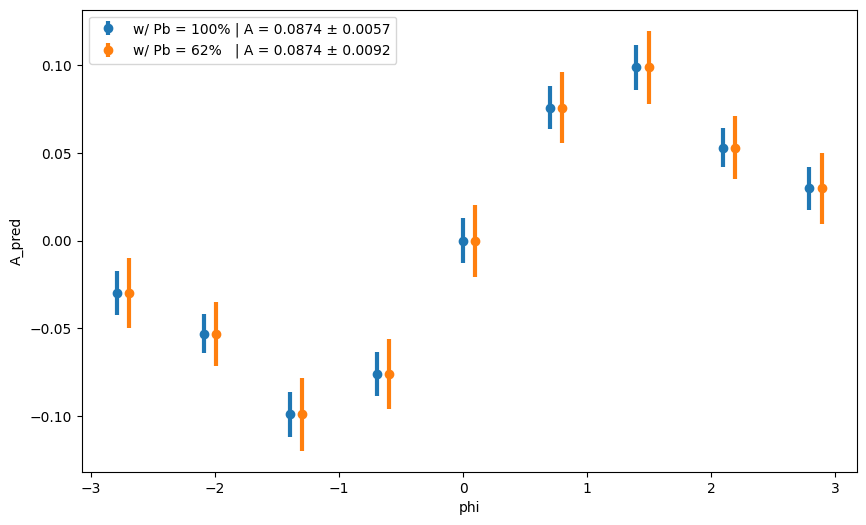

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(df['phi'], df['A_pred'], yerr=df['dA'], fmt='o', label=f'w/ Pb = 100% | A = {A:.4f} ± {A_err:.4f}', elinewidth=3, capsize=0)
ax.errorbar(df['phi']+0.1, df['A_pred'], yerr=df['dA_2026'], fmt='o', label=f'w/ Pb = 62%   | A = {A_62:.4f} ± {A_62_err:.4f}', elinewidth=3, capsize=0)

ax.set_xlabel('phi')
ax.set_ylabel('A_pred')
plt.legend(loc='upper left')

In [11]:
import gspread

gc = gspread.service_account(filename="service-account.json")

sheet = gc.open_by_key("1vkTK3yERPmYtICiybPn_eQwHTDmxNiW9isfeX3FcD2I")
worksheet = sheet.worksheet("Sheet1")

rows = worksheet.get_all_records()
df = pd.DataFrame(rows)

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'service-account.json'